### Exercise-Book

Work provided by my supervisors

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
t = np.arange(0, 100)
x_t = np.sin(0.1 * np.pi * t)

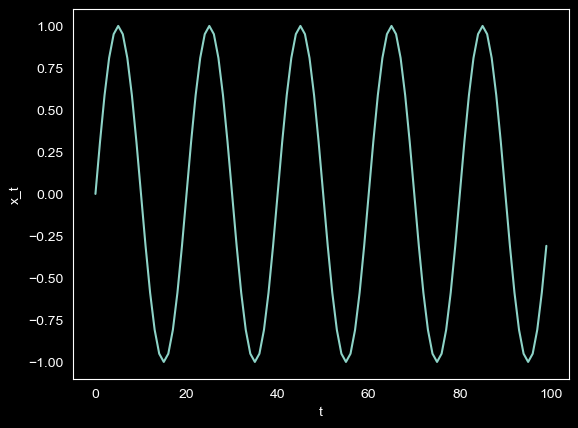

In [11]:
plt.plot(t, x_t)
plt.xlabel("t")
plt.ylabel("x_t")
plt.grid()
plt.show()

In [28]:
ε1,ε2,ε3,ε4  = 0.05, 0.25, 0.5, 0.78
shape = (len(x_t), len(x_t))
R1, R2, R3, R4 = [np.zeros(shape, dtype=bool) for _ in range(4)]

In [29]:
for i in range(len(x_t)) :
    for j in range(len(x_t)) :
        Δ = abs(x_t[i] - x_t[j])
        R1[i,j] = Δ <= ε1
        R2[i,j] = Δ <= ε2
        R3[i,j] = Δ <= ε3
        R4[i,j] = Δ <= ε4

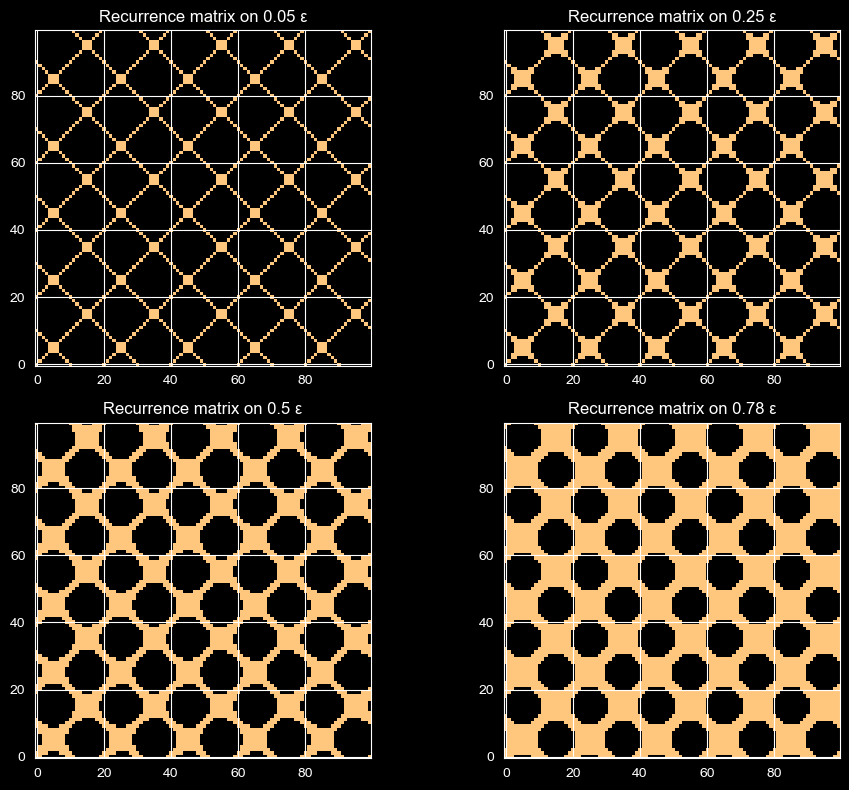

In [31]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax[0,0].imshow(R1, cmap="copper", origin="lower", interpolation="nearest")
ax[0,1].imshow(R2, cmap="copper", origin="lower", interpolation="nearest")
ax[1,0].imshow(R3, cmap="copper", origin="lower", interpolation="nearest")
ax[1,1].imshow(R4, cmap="copper", origin="lower", interpolation="nearest")

ax[0,0].set_title("Recurrence matrix on 0.05 ε")
ax[0,1].set_title("Recurrence matrix on 0.25 ε")
ax[1,0].set_title("Recurrence matrix on 0.5 ε")
ax[1,1].set_title("Recurrence matrix on 0.78 ε")

#fig1.colorbar(im, ax=ax1, label="Distance")
plt.tight_layout()
plt.show()

### Observations

Smaller ε -> reccurence rate shrinks
Larger ε -> reccurence rate grows

It is only natural that such values of ε will lead to such results. What is important is determining how to choose an ε s.t. results aren't forced in either direction : we want the recurrence plot to capture enough information, while filtering out the noise.

In [35]:
# Randomly chosen values, not sure if they are good/bad
m = 4
t = 2

windows = np.lib.stride_tricks.sliding_window_view(x_t, (m - 1) * t + 1)
vectors = windows[:, ::t] # keep slices with a delay of t

In [36]:
for i in range(len(vectors)):
    for j in range(len(vectors)):

        # Use Euc Distance
        Δ = (vectors[i] - vectors[j]) ** 2
        Δ = np.sqrt(np.sum(Δ))

        R1[i,j] = Δ <= ε1
        R2[i,j] = Δ <= ε2
        R3[i,j] = Δ <= ε3
        R4[i,j] = Δ <= ε4

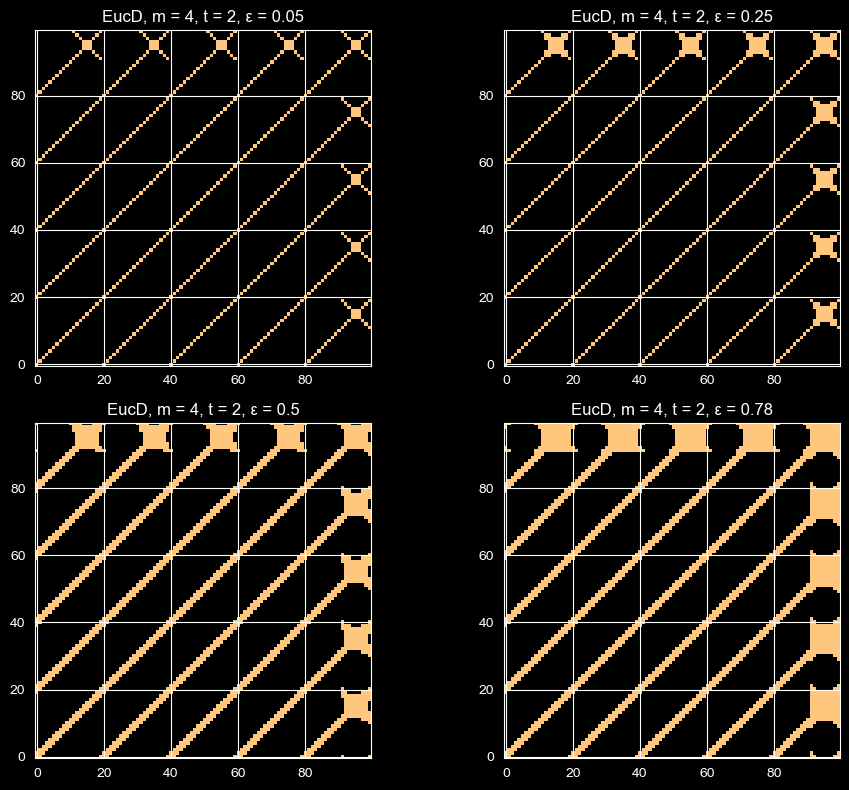

In [38]:
fig1, ax1 = plt.subplots(2, 2, figsize=(10, 8))
ax1[0,0].imshow(R1, cmap="copper", origin="lower", interpolation="nearest")
ax1[0,1].imshow(R2, cmap="copper", origin="lower", interpolation="nearest")
ax1[1,0].imshow(R3, cmap="copper", origin="lower", interpolation="nearest")
ax1[1,1].imshow(R4, cmap="copper", origin="lower", interpolation="nearest")

ax1[0,0].set_title("EucD, m = 4, t = 2, ε = 0.05")
ax1[0,1].set_title("EucD, m = 4, t = 2, ε = 0.25")
ax1[1,0].set_title("EucD, m = 4, t = 2, ε = 0.5")
ax1[1,1].set_title("EucD, m = 4, t = 2, ε = 0.78")

#fig1.colorbar(im, ax=ax1, label="Distance")
plt.tight_layout()
plt.show()